# QF 627 Programming and Computational Finance
## Mock Assessment Paper 3: 1-Hour Practice Exam

***

> Good day, Team 👋

> This is a **shorter 1-hour mock assessment** designed to help you practice core concepts efficiently. It covers the essential topics: **data wrangling**, **rule-based trading**, **supervised learning**, and **unsupervised learning** fundamentals.

> This condensed format simulates a time-pressured environment while testing your understanding of key concepts.

***

> **Time allocation**: You have **1 hour** to complete this assessment.

> **Format**: Open-book assessment. Focus on accuracy and time management.

> **Submission**: Save as `YourLastName_MockExam_1Hour.ipynb`

> **Strategy**: Answer what you know first, then return to challenging questions if time permits.

***

> Best wishes! ⏱️

***

### For standardization of your answers…

> Please execute the lines of code below before you start work on your answers.

In [1]:
# Our standardized printing options

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

np.set_printoptions(precision = 3)

pd.set_option("display.float_format", lambda x: "%.3f" % x)

plt.style.use("ggplot")

mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.color"] = "grey"
mpl.rcParams["grid.alpha"] = 0.25

mpl.rcParams["axes.facecolor"] = "white"

mpl.rcParams["legend.fontsize"] = 14

## List of Questions

    IMPORTANT NOTE: 

### <font color = purple> <center> Data wrangling and proper function implementation are critical.

### <font color = purple> <center> Write all functions within this script.

***
# SECTION A: Rule-Based Trading (50 points)
***

##  <font color = blue> 👉 Question 1. </font> Data Import and Simple Moving Average Strategy (25 points)

### Download price data for **Amazon (AMZN)** from Yahoo Finance for **January 1, 2018 to December 31, 2022**.

### Implement a dual moving average crossover strategy:

**Strategy Rules**:
- Calculate 30-day and 90-day Simple Moving Averages
- **Buy Signal (Signal = 1)**: SMA_30 > SMA_90
- **Sell Signal (Signal = 0)**: SMA_30 < SMA_90

**For rolling statistics**: `min_periods = 1`, `center = False`

### Assumptions:
- Initial capital: **$100,000**
- Trade **200 shares** when signal is 1
- Use `Adj Close` price

### Tasks:

a) Download and check the data for missing values (use forward-fill if needed)

b) Implement the moving average strategy

c) Calculate total P&L

d) Calculate the Sharpe ratio (annualized, 252 trading days)

e) Report the maximum drawdown (%)

f) Visualize the price with both moving averages

### Below are the lines of code that lead to an answer:

In [2]:
# import yfinance as yf
# import pandas as pd
# from datetime import datetime

# # Define the two groups of tickers
# group1_tickers = ['AMZN', 'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA']
# # group2_tickers = ['XLF', 'XLE', 'XLK', 'XLV', 'XLI', 'XLY', 'XLP', 'XLU', 'XLRE']

# # Define the date range
# start_date = '2015-01-01'
# end_date = datetime.today().strftime('%Y-%m-%d')

# print(f"Downloading data from {start_date} to {end_date}...")

# # Download Group 1: ETF_A, ETF_B, Stock_A, Stock_B
# print("\nDownloading Group 1 (SPY, QQQ, JPM, GS)...")
# group1_data = yf.download(group1_tickers, start=start_date, end=end_date
#                           , auto_adjust=False)
# group1_data.to_csv('mock_3.csv')
# print("saved to: mock_3.csv")

# print("\n✓ Download complete!")
# print(f"Group 1 shape: {group1_data.shape}")

In [3]:
import yfinance as yf
import datetime as dt

# Download data
start_date = "2018-01-01"
end_date = "2022-12-31"

In [4]:
# TODO csv download
def download_csv_data(file_path):
    """
    Download stock data from a CSV file
    """
    stock_data = pd.read_csv(file_path, 
                            index_col=0, 
                            parse_dates=True,
                            header=[0,1]
                            )
    return stock_data



In [5]:
# Your code here

stock_data = download_csv_data('mock_3.csv')

In [6]:
amzn = stock_data['Adj Close'][['AMZN']].loc[start_date:end_date]

In [7]:
amzn.isnull().sum()

Ticker
AMZN    0
dtype: int64

In [8]:
def get_momentum_strategy(df, sma_ls, shares, position_shift=1):
    """
    Apply single stock momentum strategy pipeline to price DataFrame `df`. 
    Price is in first column.
    Adds columns:
      positions, trade, passive_returns, strategy_returns,
      cum_returns, cum_strategy_returns
    Parameters:
      df        : pd.DataFrame with price columns for ticker name as the header
      sma_tuple : tuple of (short_window, long_window) for SMAs
    Returns:
      pd.DataFrame with the above columns
    """
    def get_pnl(df, shares_):
        df['pnl'] = df[df.columns[0]].diff() * shares_ * df['positions']
        df['pnl'] = df['pnl'].fillna(0)
        
        return df
    def get_sma(df, sma_list):
        """
        Take DF and given list of SMA to enrich df when stock price is in first column
        """
        for window in sma_list:
            df[f"sma_{window}"] =\
            (
                df[df.columns[0]]
                .rolling(window = window,
                         min_periods = 1,
                         center = False)
                .mean()
            )

        return df
    if sma_ls[0] >= sma_ls[1]:
        raise ValueError("sma_short must be less than sma_long")
    df = get_sma(df, sma_ls).dropna()

    df['positions'] =\
    (
        np.where((df[f'sma_{sma_ls[0]}'] > df[f'sma_{sma_ls[1]}']), 1, 0)
    )
    df['positions'] = df['positions'].shift(position_shift).fillna(0)
    df['trade'] = \
    (
        df['positions'].diff().fillna(0)
    )
    if df.at[df.index[0], 'positions'] != 0:
        df.at[df.index[0], 'trade'] = df.at[df.index[0], 'positions']
    df['passive_returns'] =\
    (    # get passive returns
        np.log(df[df.columns[0]] 
            / df[df.columns[0]].shift(1))
    ).fillna(0)
    df['strategy_returns'] =\
    (     # get strategy returns
        df['passive_returns'] * df['positions'].shift(1).fillna(0)
    )
    df['cum_returns'] =\
    (
        df['passive_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df['cum_strategy_returns'] =\
    (
        df['strategy_returns'].cumsum().apply(np.exp).fillna(1)
    )
    df = get_pnl(df,shares)

    return df

sma_list = [30, 90]
amzn = get_momentum_strategy(amzn, sma_list, shares=200, position_shift=1)

In [9]:
def calculate_sharpe_ratio(returns, freq = 252):
    """
    Calculate annualized Sharpe ratio
    """
    mu = returns.mean()
    sigma = returns.std(ddof = 0)
    return np.sqrt(freq) * (mu / sigma)

In [10]:
def calculate_max_drawdown(df, price_column = "Adj Close"):
    """
    Calculate maximum drawdown percentage
    """
    price_series = df[price_column].astype(float)
    wealth = price_series / price_series.iloc[0]
    peak = wealth.cummax()
    drawdown = (wealth - peak) / peak
    max_dd = -drawdown.min() * 100
    return max_dd

In [11]:
# Calculate maximum drawdown
"""
TODO get_drawdown_top max drawdown and duration table
"""
from lets_plot import *
LetsPlot.setup_html()

def get_drawdowns_plot(df):
    df['daily_drawdown'] = df['cum_strategy_returns'] / df['cum_strategy_returns'].cummax() - 1
    # take date column out and cumsum for periods
    dd_reset = df.reset_index()
    dd_reset['period'] = (dd_reset['daily_drawdown'] == 0).cumsum()
    # find nodes with 0 value i.e. highpoints
    dd_nonzero = dd_reset[dd_reset['daily_drawdown'] != 0]
    # aggregate by period
    period_stats = dd_nonzero.groupby('period').agg(
        start_date = ('Date', 'min'),
        end_date = ('Date', 'max'),
        avg_dd = ('daily_drawdown', 'mean'),
        max_dd = ('daily_drawdown', 'min'),
        duration=('daily_drawdown', 'count')
    ).sort_values(by='avg_dd',ascending=True)


    ## printing drawdowns
    for i, row in enumerate(period_stats.itertuples(), start=1):
        ordinal = f"{i}{'tsnrhtdd'[i%5*(i%100^15>4>i%10)::4]}"
        print(f"The {ordinal} worst drawdown period : Net drawdown {-row.max_dd:.2%}% | Duration {row.duration} Days\n")


    # plot drawdowns
    # from lets_plot import *
    # LetsPlot.setup_html()
    p =\
    (
        ggplot(dd_reset, aes(x='Date')) +
        geom_line(aes(y='daily_drawdown'), color='grey', size=0.7) +
        # geom_line(aes(y='sma_50'), color='orange', size=0.7,linetype=2) +   # amend sma as required
        # geom_line(aes(y='sma_200'), color='blue', size=0.7,linetype=2) +
        # geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']>0.0], color='red', size=3) +       # amend trade as required
        # geom_point(aes(y='sma_50'), data=wmt_melt[wmt_melt['trade']<-0.0], color='blue', size=3) +
        ggtitle(f"Drawdown") +
        ylab("pct loss") +
        scale_y_continuous(format='.0%') + 
        xlab("Date") +
        ggsize(1200, 500) 
    )
    display(p)

    return period_stats


amzn_dd = get_drawdowns_plot(amzn)


The 1st worst drawdown period : Net drawdown 46.32%% | Duration 586 Days

The 2nd worst drawdown period : Net drawdown 26.81%% | Duration 443 Days

The 3rd worst drawdown period : Net drawdown 14.16%% | Duration 38 Days

The 4th worst drawdown period : Net drawdown 7.44%% | Duration 17 Days

The 5th worst drawdown period : Net drawdown 5.12%% | Duration 13 Days

The 6th worst drawdown period : Net drawdown 4.62%% | Duration 9 Days

The 7th worst drawdown period : Net drawdown 4.48%% | Duration 7 Days

The 8th worst drawdown period : Net drawdown 3.87%% | Duration 5 Days

The 9th worst drawdown period : Net drawdown 1.86%% | Duration 1 Days

The 10th worst drawdown period : Net drawdown 2.24%% | Duration 8 Days

The 11th worst drawdown period : Net drawdown 3.04%% | Duration 5 Days

The 12th worst drawdown period : Net drawdown 2.27%% | Duration 5 Days

The 13th worst drawdown period : Net drawdown 2.16%% | Duration 10 Days

The 14th worst drawdown period : Net drawdown 1.22%% | Duratio

In [12]:
# Visualization

In [13]:
def get_cagr(cumulative_returns, annual_days=365.25):
    """
    get_cagr Compute Compound Annual Growth Rate (CAGR) from a series of cumulative returns.
        NOTE: please ensure index is date
    Parameters:
        cumulative_returns : pandas.Series. Time-indexed series of cumulative returns (e.g. cumulative growth factors)
    Returns:
        float
    """

    cumulative_returns = cumulative_returns.dropna()
    n_of_days = (cumulative_returns.index[-1] - cumulative_returns.index[0]
                ).days
    cagr =\
    (
        (        
        cumulative_returns.iloc[-1] 
        /
        cumulative_returns.iloc[0]
        ) ** (annual_days / n_of_days)
        - 1
    )
    return cagr

# print(f"The answer is {max(c_dct, key=c_dct.get).upper()} with {max(c_dct.values()):.2%}")

def get_sharpe(daily_returns):
    """
    get_sharpe Calculate the annualized Sharpe ratio from a series of daily returns.
    Annualized Sharpe ratio computed as:
                sqrt(252) * mean(daily_returns) / std(daily_returns)
    - Assumes 252 trading days per year for annualization. Adjust the
      multiplier for a different convention.
    - Input should be returns (not prices). Convert prices to returns before
      calling this function.
    Parameters:
        daily_returns : array-like (pd.Series or np.ndarray)
    Returns:
        float
    Usage:
        get_sharpe_ratio(df['strategy_returns'])
    """
    return np.sqrt(252) * daily_returns.mean() / daily_returns.std(ddof = 1)

# get_sharpe_ratio(ibm['strategy_returns'])
# print(f"The answer is {max(sharpe_dct, key=s_dct.get).upper()} with  {max(sharpe_dct.values()):.5f}")

### <font color = red> Answer 1 </font>

    Total P&L: $____________
    
    Final Portfolio Value: $____________
    
    Sharpe Ratio: ____________
    
    Maximum Drawdown: ____________%
    
    Number of trading days: ____________

In [14]:
# total PNL and CAGR
initial_capital = 100_000
print(f"    Total P&L for Stock X (amzn) using Bollinger Band strategy: ${amzn.pnl.sum():,.0f}")
print(f"    Initial Capital: $100,000")
print(f"    Total P&L: ${amzn.pnl.sum():,.2f}")
print(f"    Sharpe Ratio: {get_sharpe(amzn['strategy_returns']):.5f}")
print(f"    Maximum Drawdown: {-amzn_dd.max_dd.min():.2%}")
print(f"    Final Portfolio Value: ${100_000+amzn.pnl.sum():,.2f}")
print(f"    Return: {get_cagr(amzn['cum_strategy_returns']):.2%}")

# for ticker, df in stock_dct.items():
#     print(f"{ticker}")
#     print(f"- Total P&L: ${df.pnl.sum():,.2f}")
#     print(f"- Sharpe Ratio: {get_sharpe(df['strategy_returns']):.5f}")

    Total P&L for Stock X (amzn) using Bollinger Band strategy: $-2,677
    Initial Capital: $100,000
    Total P&L: $-2,677.40
    Sharpe Ratio: -0.00039
    Maximum Drawdown: 46.32%
    Final Portfolio Value: $97,322.60
    Return: -0.01%


##  <font color = blue> 👉 Question 2. </font> Performance Metrics (25 points)

### Using the strategy from Question 1, calculate the following metrics:

### Tasks:

a) **CAGR** (Compound Annual Growth Rate)
   - Formula: `(end_value / start_value) ^ (1 / years) - 1`

b) **Calmar Ratio**
   - Formula: `CAGR / Maximum Drawdown`

c) Calculate the **longest drawdown period** in days

d) Create a visualization showing:
   - Wealth curve (normalized price)
   - Drawdown series

e) Report how many days the strategy had a positive return

### Below are the lines of code that lead to an answer:

In [15]:
get_drawdowns_plot(amzn);


The 1st worst drawdown period : Net drawdown 46.32%% | Duration 586 Days

The 2nd worst drawdown period : Net drawdown 26.81%% | Duration 443 Days

The 3rd worst drawdown period : Net drawdown 14.16%% | Duration 38 Days

The 4th worst drawdown period : Net drawdown 7.44%% | Duration 17 Days

The 5th worst drawdown period : Net drawdown 5.12%% | Duration 13 Days

The 6th worst drawdown period : Net drawdown 4.62%% | Duration 9 Days

The 7th worst drawdown period : Net drawdown 4.48%% | Duration 7 Days

The 8th worst drawdown period : Net drawdown 3.87%% | Duration 5 Days

The 9th worst drawdown period : Net drawdown 1.86%% | Duration 1 Days

The 10th worst drawdown period : Net drawdown 2.24%% | Duration 8 Days

The 11th worst drawdown period : Net drawdown 3.04%% | Duration 5 Days

The 12th worst drawdown period : Net drawdown 2.27%% | Duration 5 Days

The 13th worst drawdown period : Net drawdown 2.16%% | Duration 10 Days

The 14th worst drawdown period : Net drawdown 1.22%% | Duratio

Text(0.5, 1.0, 'AMZN 30-90 day momentum strategy Cumulative return')

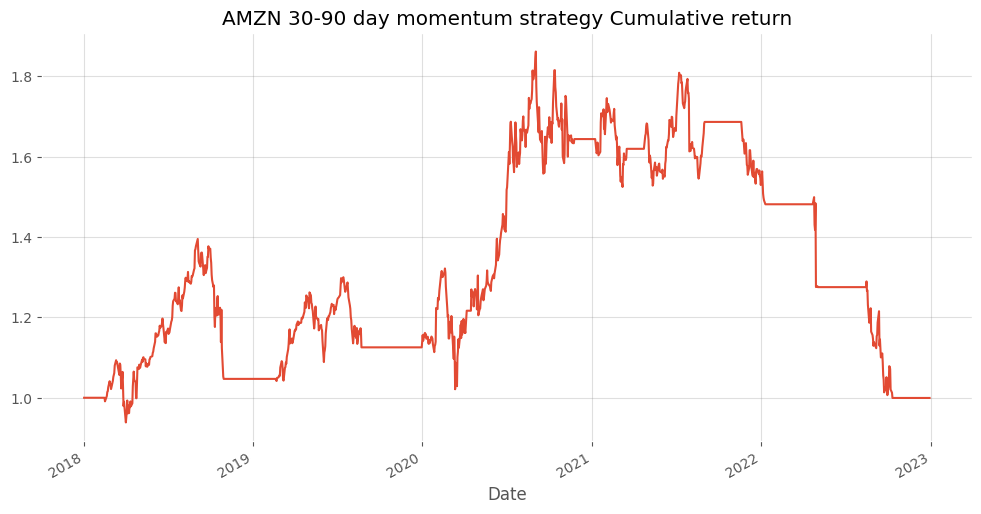

In [16]:
amzn['cum_strategy_returns'].plot(figsize=[12,6])
plt.title("AMZN 30-90 day momentum strategy Cumulative return")

In [17]:
# Count positive return days
postive_days = amzn['strategy_returns'][amzn['strategy_returns']>0].count()

### <font color = red> Answer 2 </font>

    CAGR: ____________%
    
    Calmar Ratio: ____________
    
    Longest Drawdown Period: ____________ days
    
    Days with Positive Returns: ____________
    
    Total Trading Days: ____________

In [18]:
# total PNL and CAGR
amzn_cagr = get_cagr(amzn['cum_strategy_returns'])
amzn_mdd = -amzn_dd.max_dd.min()

print(f"    CAGR: {amzn_cagr:.2%}")
print(f"    Calmar Ratio: {amzn_cagr / amzn_mdd :.5f}")
print(f"    Longers Drawdown: {amzn_dd.duration.max()} days")
print(f"    Positive days: {postive_days} days")

    CAGR: -0.01%
    Calmar Ratio: -0.00021
    Longers Drawdown: 586 days
    Positive days: 399 days


***
# SECTION B: Supervised Learning (25 points)
***

##  <font color = blue> 👉 Question 3. </font> Feature Engineering and Model Training (25 points)

### Build a machine learning model to predict the **5-day return** of **AMZN** using the data from Question 1.

### Feature Engineering:

**Target (Y)**:
- 5-day return of AMZN

**Features (X)**:
- Lagged 5-day return
- Lagged 10-day return
- 20-day Simple Moving Average
- 50-day Simple Moving Average
- 14-day RSI (Relative Strength Index)

### Tasks:

a) Engineer all features

b) Drop rows with missing values

c) Split: 70% training (chronologically first 70%), 30% testing

d) Train the following models:
   - Linear Regression
   - Ridge Regression (alpha = 1.0)
   - Random Forest (n_estimators = 50, random_state = 627)

e) Calculate MSE for each model on test set

f) Report which model performs best

g) For the best model, create an actual vs predicted scatter plot

### Below are the lines of code that lead to an answer:

In [19]:
stock_data_copy = stock_data.copy()
stock_data = stock_data['Adj Close']

In [20]:
stock_data.isnull().sum()

Ticker
AAPL     0
AMZN     0
GOOGL    0
META     0
MSFT     0
NVDA     0
dtype: int64

In [21]:
# Feature engineering
target = 'AMZN'
stock_tickers = [
    "AMZN"    # Stocks
]
extract_tickers = stock_tickers

sub_df_list = []

# lagged five-day, 15-day, 30-day, and 60-day returns of NFLX.
lag_list = [5, 10]
df_rets = stock_data[[target]].copy()

for lag in lag_list:
    df_rets[f'{target}_ret_{lag}'] = df_rets[target].pct_change(lag).shift(1)
    
df_rets = df_rets.drop(columns=target)

sub_df_list.append(df_rets)

# get sma
def get_sma(df, sma_list):
    """
    Take DF and given list of SMA to enrich df when stock price is in first column
    """
    df = df.copy()
    for window in sma_list:
        df[f"sma_{window}"] =\
        (
            df[df.columns[0]]
            .rolling(window = window,
                     min_periods = int(window * .8))
            .mean()
        )

    return df

sma_list = [20, 50]
df_sma = get_sma(stock_data[[target]].copy(), sma_list).drop(columns=target)

sub_df_list.append(df_sma)


# get RSI
def get_rsi(df, period_list):
    """
    Calculate RSI (Relative Strength Index)
    Parameters:
    df: pandas df of closing price
    period_list: RSI period (default [10, 30, 200])
    Returns:
    pandas df with RSI values
    """
    # Make a copy to avoid SettingWithCopyWarning
    df = df.copy()
    
    # Calculate price changes
    delta = df[df.columns[0]].diff()
    
    for period in period_list:
        # Separate gains and losses
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        
        # get first average
        avg_gain = pd.Series(index=df.index, dtype='float64')
        avg_loss = pd.Series(index=df.index, dtype='float64')

        # get first average
        avg_gain.iloc[period] = gain.iloc[1:period+1].mean()
        avg_loss.iloc[period] = loss.iloc[1:period+1].mean()

        # Calculate rolling averages
        for i in range(period + 1, len(df)): 
            avg_gain.iloc[i] = (avg_gain.iloc[i-1] * (period - 1) + gain.iloc[i]) / period
            avg_loss.iloc[i] = (avg_loss.iloc[i-1] * (period - 1) + loss.iloc[i]) / period

        # Calculate RS (Relative Strength)
        rs = avg_gain / avg_loss
        
        # Calculate RSI
        rsi = 100 - (100 / (1 + rs))

        df[f'rsi_{period}'] = rsi
        
    return df

rsi_list = [14]
df_rsi = get_rsi(stock_data[[target]].copy(), rsi_list).drop(columns=target)

sub_df_list.append(df_rsi)


# get target forward returns with lag
# y parameter
def get_target_parameter(df, target, fwd=5, lag=1):
    df_fwd_rets = df[[target]].copy()
    df_fwd_rets[f"{target}_fwd_rets"] = df_fwd_rets.pct_change(fwd).shift(-fwd-lag) 
                            # get fwd rets, shift by same amount, only trade day after signal computed
    return df_fwd_rets.drop(columns=target)

df_fwd_rets = get_target_parameter(stock_data, target, fwd=5, lag=1)

sub_df_list.append(df_fwd_rets)


In [22]:
# combine df
df_combined =\
(
    pd.concat(sub_df_list,axis=1)
)
# fill forward for NaN
df_combined =\
(
    df_combined.ffill().dropna()
)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare features and target
X = df_combined.drop(columns=[f'{target}_fwd_rets'])
y = df_combined[f'{target}_fwd_rets']  # Note: removed extra brackets for cleaner y

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=627, shuffle=False
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# establish metrics 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse_results = {}

def get_mse_train_test(model, X_train, y_train, X_test, y_test, name=None):
    """
    Compute MSE on train and test and store results in mse_results.
    If name is not provided, use model class name.
    """
    global mse_results
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)

    y_test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, y_test_pred)

    model_name = name or model.__class__.__name__
    if model_name == "GridSearchCV":
        model_name = str(type(model.best_estimator_)).split(".")[-1].replace("'>", "")
    

    mse_results[str(model_name)] = {
                                    'mse_train': mse_train, 
                                    'mse_test': mse_test
                                }

    print(f"Mean Squared Error (MSE) for {model_name}")
    print(f"MSE train: {mse_train:.6f}")
    print(f"MSE test: {mse_test:.6f}")

    return mse_train, mse_test

In [25]:
# instantiate models
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha = 10.0),
    # 'Lasso': Lasso(alpha = 0.01),
    # 'Elastic Net': ElasticNet(alpha = 0.01, l1_ratio = 0.5),
    # 'KNN': KNeighborsRegressor(n_neighbors = 10),
    # 'Decision Tree': DecisionTreeRegressor(max_depth = 5, random_state = 627),
    # 'Gradient Boosting': GradientBoostingRegressor(n_estimators = 100, max_depth = 3, random_state = 627),
    'Random Forest': RandomForestRegressor(n_estimators = 100, max_depth = 10, random_state = 627)
}

for model_name, model in models.items():
    fit_model = model.fit(X_train_scaled, y_train)
    get_mse_train_test(fit_model, 
                   X_train_scaled, 
                   y_train, 
                   X_test_scaled,
                   y_test, 
                   name=model_name)

Mean Squared Error (MSE) for Linear Regression
MSE train: 0.001930
MSE test: 0.002104
Mean Squared Error (MSE) for Ridge
MSE train: 0.001931
MSE test: 0.002088
Mean Squared Error (MSE) for Random Forest
MSE train: 0.000810
MSE test: 0.002758


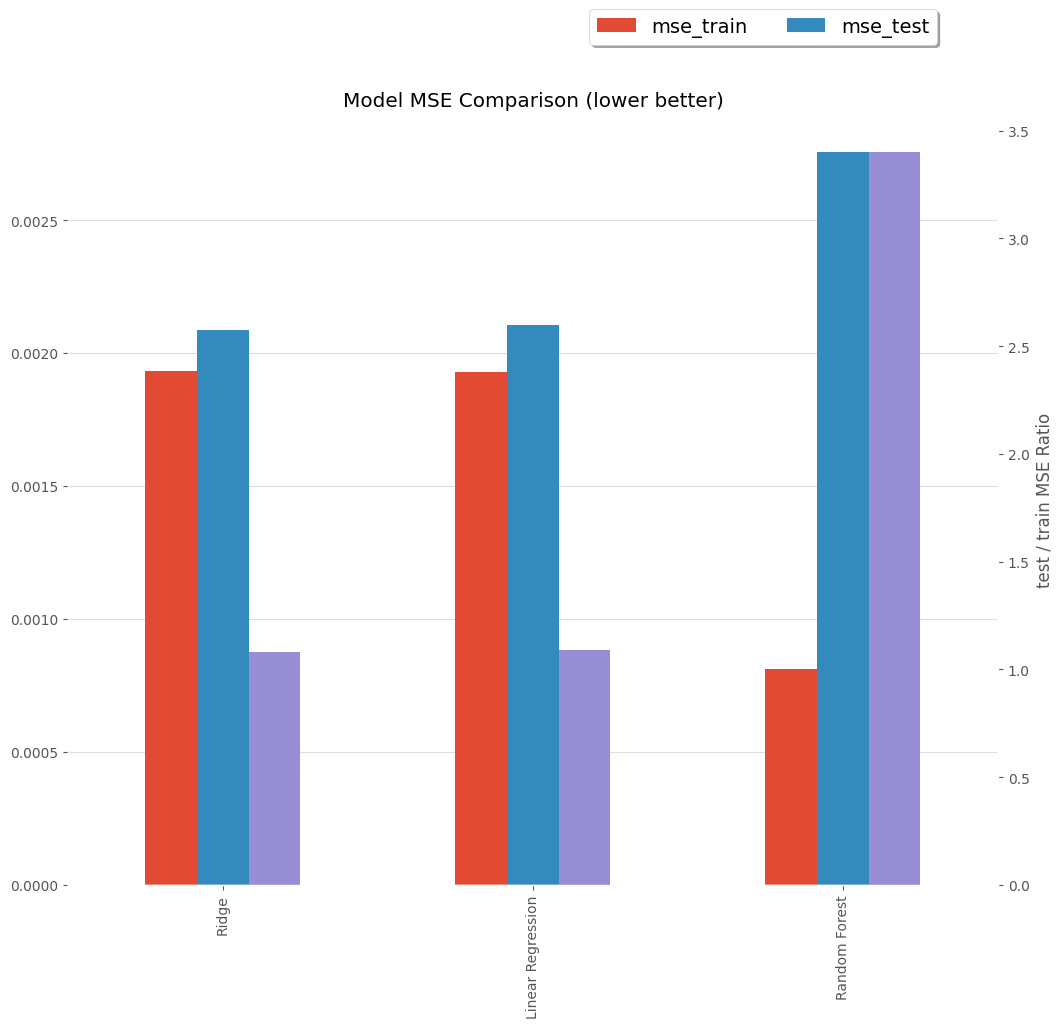

In [26]:
# Calculate MSE for each model
# get results DataFrame

## Create results dataframe
metrics = pd.DataFrame(mse_results).T.sort_values(by='mse_test')
metrics['mse_ratio'] = metrics['mse_test'] / metrics['mse_train']
metrics

## Visualization of model comparison
ax =\
(
    metrics[['mse_train', 'mse_test', 'mse_ratio']].plot(
        secondary_y = 'mse_ratio',
        kind='bar',
        title='Model MSE Comparison (lower better)',
        ylabel='test / train MSE Ratio',
        figsize=(12, 10)
    )
)

ax.xaxis.grid(False)

(
    ax
    .legend(loc = "upper left",
            bbox_to_anchor = (0.55, 1.15),
            ncol = 4,
            shadow = True
           )
)

In [27]:
# Actual vs Predicted plot for best model
model = models['Ridge']
lr = model.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)



In [28]:
model.coef_

array([ 9.115e-05, -6.880e-04, -1.167e-02,  6.337e-03, -2.846e-03])

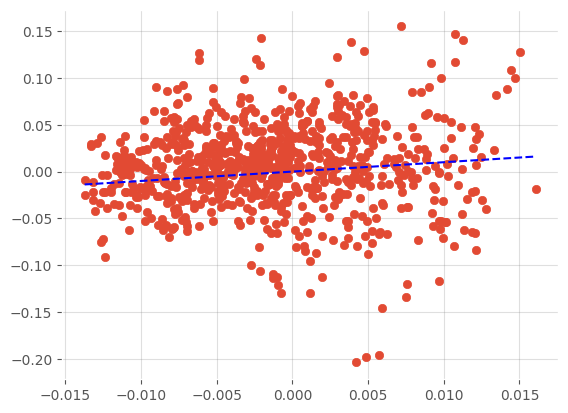

In [29]:
plt.scatter(y_pred, y_test)

r_min = y_pred.min().min()
r_max = y_pred.max().max()

np.linspace(r_min, r_max, 100)
# rets.plot(kind='scatter')


ln_x = np.linspace(r_min, r_max, 100)
ln_y = np.linspace(r_min, r_max, 100)
plt.plot(ln_x, ln_y, 'b--')

### <font color = red> Answer 3 </font>

    Number of features: ____________
    
    Training set size: ____________
    Testing set size: ____________
    
    Model Performance (Test MSE):
    - Linear Regression: ____________
    - Ridge: ____________
    - Random Forest: ____________
    
    Best Model: ____________

In [30]:
print(f"    Number of features: {X_train.shape[1]}")
print(f"    Training set size: {X_train.shape[0]}")
print(f"    Testing set size: {X_test.shape[0]}")
display(metrics)
print(f"Best model: \n{metrics.iloc[0]}")

    Number of features: 5
    Training set size: 1884
    Testing set size: 808


,mse_train,mse_test,mse_ratio
Ridge,0.002,0.002,1.081
Linear Regression,0.002,0.002,1.091
Random Forest,0.001,0.003,3.403


Best model: 
mse_train   0.002
mse_test    0.002
mse_ratio   1.081
Name: Ridge, dtype: float64


***
# SECTION C: Unsupervised Learning (25 points)
***

##  <font color = blue> 👉 Question 4. </font> K-Means Clustering (15 points)

### Download data for 6 major tech stocks from **January 1, 2019 to December 31, 2022**:

**AAPL, MSFT, GOOGL, AMZN, META, NVDA**

### Tasks:

a) Download Adjusted Close prices

b) Calculate for each stock:
   - Annualized return = mean(daily_returns) × 252
   - Annualized volatility = std(daily_returns) × √252

c) Create feature matrix [Return, Volatility] and standardize

d) Apply K-Means clustering with k = 2 and k = 3

e) Visualize clusters (Return vs Volatility scatter plot)

f) For k = 3, report which stocks are in each cluster

g) Calculate the silhouette score for k = 2 and k = 3

### Below are the lines of code that lead to an answer:

In [31]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [32]:
# Download tech stocks
tech_stocks = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA']
start_date = '2019-01-01'
end_date = '2023-01-01'
data = stock_data.loc[start_date: end_date]

In [33]:
# Calculate returns and volatility
# TODO: get_annual_returns dataframe
# prepare annual returns
ann_rets = data.pct_change().mean() * 252
ann_vols = data.pct_change().std() * np.sqrt(252)

df = \
(
    pd.DataFrame({'return': ann_rets, 'volatility': ann_vols})
)

# SCALED DATA FOR CLUSTERING
scaler = StandardScaler()
data = scaler.fit_transform(df)

df = pd.DataFrame(data, columns=df.columns, index=df.index)

X = df.copy()

In [34]:
df

,return,volatility
Ticker,,
AAPL,0.772,-0.523
AMZN,-1.051,-0.370
GOOGL,-0.436,-0.842
META,-1.141,0.782
MSFT,0.191,-0.904
NVDA,1.665,1.857


In [35]:
df.columns

Index(['return', 'volatility'], dtype='object')

    2 Cluster assignments:
    - Cluster 0: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT']
    - Cluster 1: ['NVDA']
    Silhouette Score: 0.45225378641711894


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_1430/691293760.py:49: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "sg" (-> color='g'). The keyword argument will take precedence.
  plt.plot(centroids[:,0],


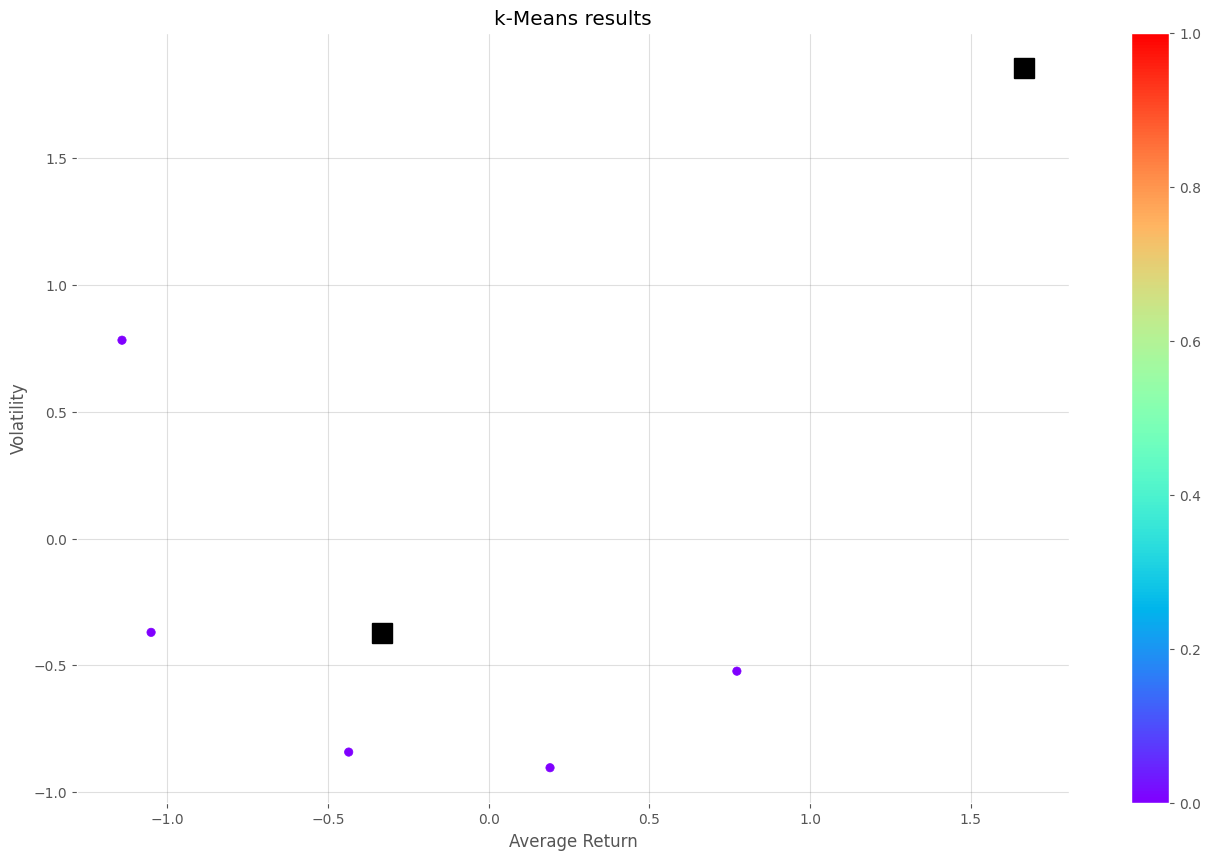

    3 Cluster assignments:
    - Cluster 0: ['AMZN', 'META']
    - Cluster 1: ['NVDA']
    - Cluster 2: ['AAPL', 'GOOGL', 'MSFT']
    Silhouette Score: 0.3303211666069801


/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_1430/691293760.py:49: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "sg" (-> color='g'). The keyword argument will take precedence.
  plt.plot(centroids[:,0],


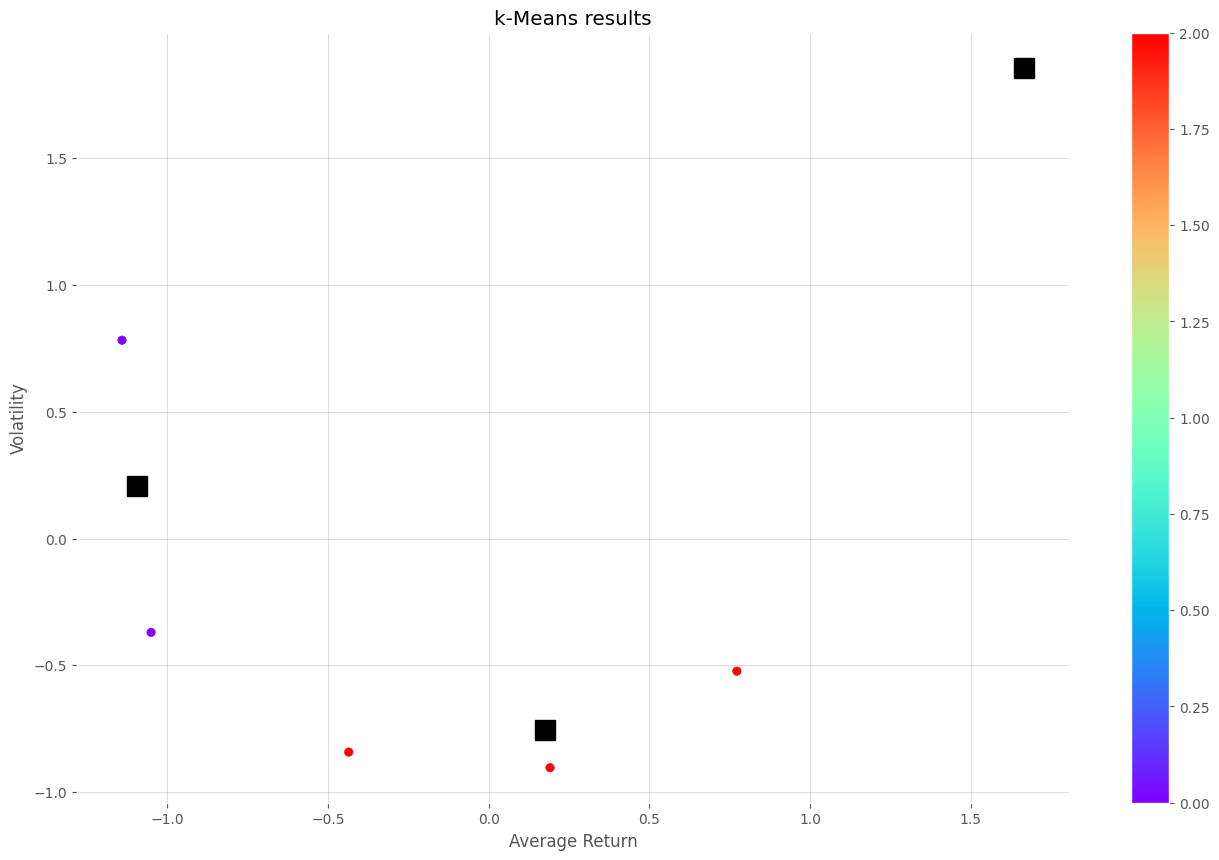

In [36]:
"""
Elbow method and pick optimal k based on silhouette
"""
from sklearn import cluster 
from sklearn.metrics import silhouette_score

# Apply K-Means with optimal k
k_ls = [2, 3]   # TODO find optimal k to replace this value


for optimal_k in k_ls:
    # Fit with k-means
    k_means = cluster.KMeans(n_clusters=optimal_k)
    k_means.fit(X)

    # plot 
    ## Visualize clusters
    centroids = k_means.cluster_centers_

    print(f"    {optimal_k} Cluster assignments:")
    cluster_df = pd.DataFrame({'ticker': df.index, 'cluster': k_means.labels_})
    for cluster_id in sorted(cluster_df['cluster'].unique()):
        tickers = cluster_df[cluster_df['cluster'] == cluster_id]['ticker'].tolist()
        print(f"    - Cluster {cluster_id}: {tickers}")
    print(f"    Silhouette Score: {silhouette_score(X, k_means.labels_, random_state = 627)}")
    

    fig = plt.figure(figsize=(16,10)
                    )

    ax = fig.add_subplot(111)

    scatter =\
    (    
        ax
        .scatter(X.iloc[ : ,0], 
                X.iloc[ : ,1], 
                c = k_means.labels_, 
                cmap = "rainbow", 
                label = X.index)
    )

    ax.set_title("k-Means results")
    ax.set_xlabel("Average Return")
    ax.set_ylabel("Volatility")

    plt.colorbar(scatter)

    plt.plot(centroids[:,0], 
            centroids[:,1], 
            "sg", 
            markersize = 15, 
            color = "black")
    plt.show()

# PLEASE NOTE THAT ALL THE RETURNS AND VOLS IN THIS PLOT ARE SCALED
##########################################

In [37]:
# Calculate silhouette scores

### <font color = red> Answer 4 </font>

    K-Means with k=2:
    - Cluster 0: ____________
    - Cluster 1: ____________
    - Silhouette Score: ____________
    
    K-Means with k=3:
    - Cluster 0: ____________
    - Cluster 1: ____________
    - Cluster 2: ____________
    - Silhouette Score: ____________
    
    Better clustering (higher silhouette): k = ____________

    Better clustering (higher silhouette): k = 3

##  <font color = blue> 👉 Question 5. </font> Hierarchical Clustering (10 points)

### Using the same standardized feature matrix from Question 4:

### Tasks:

a) Compute the linkage matrix using **Ward** method

b) Create a dendrogram with stock labels

c) Cut the dendrogram to create 3 clusters

d) Compare the hierarchical clustering results (3 clusters) with K-Means results (k=3) from Question 4

e) Report which stocks are assigned to different clusters between the two methods

### Below are the lines of code that lead to an answer:

In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

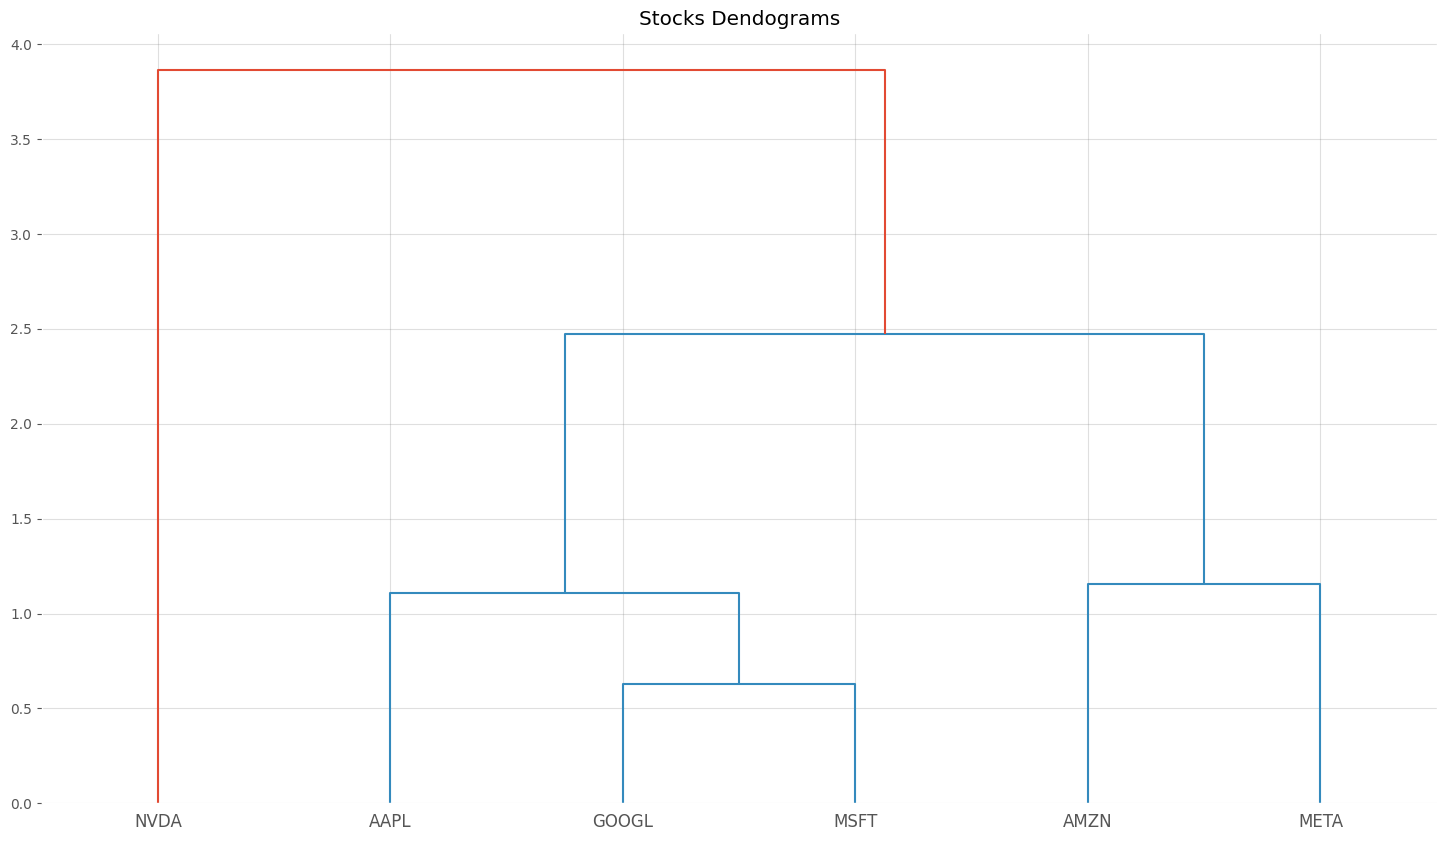

array([1, 2, 3], dtype=int32)

In [39]:
# Compute linkage matrix (Ward method)
# model fit
from scipy.cluster.hierarchy import dendrogram, linkage, ward
#Calulate linkage
Z = linkage(X, 
            method = "ward")
# Plot Dendogram

plt.figure(figsize=(18, 10)
          )
plt.title("Stocks Dendograms")

dendrogram(Z, labels = X.index)

plt.show()

from sklearn.cluster import AgglomerativeClustering
# from sklearn.cluster import KMeans, AgglomerativeClustering,AffinityPropagation, DBSCAN
from scipy.cluster.hierarchy import fcluster
# from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
# from scipy.spatial.distance import pdist
# from sklearn.metrics import adjusted_mutual_info_score
# from sklearn import cluster, covariance, manifold

# choose a cluster from the longest vertical line
distance_threshold = 1.5

clusters = fcluster(Z, distance_threshold, criterion='distance')

chosen_clusters = pd.DataFrame(data=clusters, 
                               columns=['cluster']
                              )
display(chosen_clusters['cluster'].unique())

# do the transformation to assign clusters
# agglomarative clustering
nclust = 3

hc = AgglomerativeClustering(n_clusters = nclust, 
                             linkage = "ward")

clust_labels1 = hc.fit_predict(X)

In [40]:
clust_labels1

array([2, 0, 2, 0, 2, 1])

In [41]:
res_df = df.copy()

In [42]:
# Compare with K-Means
res_df['kmeans'] = k_means.labels_
res_df['agglo'] = clust_labels1

In [43]:
res_df

,return,volatility,kmeans,agglo
Ticker,,,,
AAPL,0.772,-0.523,2,2
AMZN,-1.051,-0.370,0,0
GOOGL,-0.436,-0.842,2,2
META,-1.141,0.782,0,0
MSFT,0.191,-0.904,2,2
NVDA,1.665,1.857,1,1


### <font color = red> Answer 5 </font>

    Hierarchical Clustering (3 clusters):
    - Cluster 1: ____________
    - Cluster 2: ____________
    - Cluster 3: ____________
    
    Stocks in different clusters (K-Means vs Hierarchical):
    ____________
    
    Most similar stocks (merge first in dendrogram):
    ____________ and ____________

***
# SUBMISSION CHECKLIST
***

### Before submitting, ensure:

- [ ] All code cells executed successfully
- [ ] All answer cells completed
- [ ] Visualizations display correctly
- [ ] Functions written within notebook
- [ ] Workspace displayed with `%whos`
- [ ] File saved as: `YourLastName_MockExam_1Hour.ipynb`

In [44]:
%whos

Variable                     Type                       Data/Info
-----------------------------------------------------------------
AgglomerativeClustering      type                       <class 'sklearn.cluster._<...>AgglomerativeClustering'>
DecisionTreeRegressor        ABCMeta                    <class 'sklearn.tree._cla<...>s.DecisionTreeRegressor'>
GGBunch                      type                       <class 'lets_plot.plot.plot.GGBunch'>
GradientBoostingRegressor    ABCMeta                    

TypeError: object of type 'ABCMeta' has no len()

### <font color = green> 💯 Thank you for completing the 1-hour mock assessment!

### Coverage Summary:

✅ **Rule-Based Trading** (50 points)
- Dual moving average strategy
- P&L calculation
- Sharpe ratio, CAGR, Calmar ratio
- Drawdown analysis

✅ **Supervised Learning** (25 points)
- Feature engineering with RSI
- 3 ML models comparison
- MSE evaluation

✅ **Unsupervised Learning** (25 points)
- K-Means clustering
- Hierarchical clustering with dendrogram
- Silhouette score analysis

***

### Total: 100 points | Time: 1 hour

***

### Good luck! 🎯